# Hands-On 8: Imbalance, weights and thresholds

Worked responses accompany the same experiments.

In [1]:
from pathlib import Path
import os
import sys
try:
    import mlcourse.setup
except ModuleNotFoundError:
    bases = [Path(os.environ.get("MLCOURSE_ROOT", Path.cwd())), Path.cwd(), Path("/content/pp-machine-learning")]
    for base in bases:
        for candidate in (base.resolve(), *base.resolve().parents):
            if (candidate / "src/mlcourse/setup.py").is_file():
                sys.path.insert(0, str(candidate / "src"))
                break
        else:
            continue
        break
    else:
        raise RuntimeError("Course files not found. Open the extracted course repository or set MLCOURSE_ROOT to its location.") from None

In [2]:
from mlcourse.setup import setup_notebook
REPO_ROOT = setup_notebook()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from mlcourse.labs import load_course_data

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from mlcourse.labs import make_imbalance_data, split_classification, binary_metrics
from mlcourse.widgets import interactive_threshold

## 1. Inspect the class distribution

Generate the two-feature dataset and create a stratified split.

**Prediction:** Could a model obtain high accuracy while predicting only class `0`?

Yes. Most observations belong to class `0`, so many correct predictions could hide complete failure on class `1`.

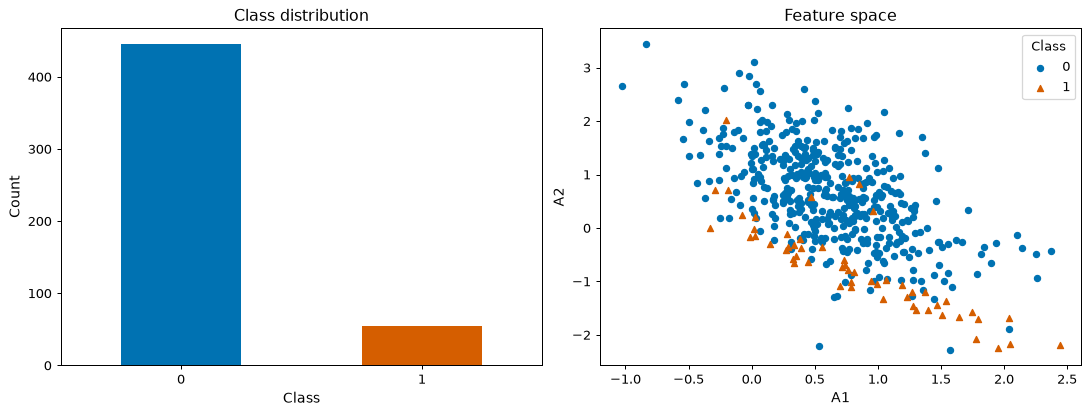

,train_count,test_count
class,,
0,311,134
1,39,16


In [3]:
X, y = make_imbalance_data()
X_train, X_test, y_train, y_test = split_classification(X, y)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
y.value_counts().sort_index().plot.bar(ax=axes[0], color=['#0072B2', '#D55E00'], rot=0)
axes[0].set(xlabel='Class', ylabel='Count', title='Class distribution')
for value, marker, color in [(0, 'o', '#0072B2'), (1, '^', '#D55E00')]:
    axes[1].scatter(X.loc[y == value, 'A1'], X.loc[y == value, 'A2'], marker=marker, color=color, s=24, label=str(value))
axes[1].set(xlabel='A1', ylabel='A2', title='Feature space')
axes[1].legend(title='Class')
plt.show()
display(pd.DataFrame({'train_count': y_train.value_counts(), 'test_count': y_test.value_counts()}))

**Observation:** Compare class counts in both partitions.

The training partition contains 311 majority and 39 minority examples; the test partition contains 134 and 16. Both preserve approximately the same imbalance.

**Explanation:** Why does stratification help make the comparison interpretable?

Stratification keeps class proportions approximately comparable across partitions. This makes metric changes easier to attribute to the classifier rather than to an accidental change in class balance.

## 2. Establish a simple baseline

Compare an always-majority prediction with a depth-two decision tree.

**Prediction:** Which metric will expose the majority classifier most clearly?

Minority recall will be zero for an always-majority prediction.

In [4]:
shallow_tree = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X_train, y_train)
results = pd.DataFrame({
    'Always majority': binary_metrics(y_test, np.zeros(len(y_test), dtype=int)),
    'Depth-two tree': binary_metrics(y_test, shallow_tree.predict(X_test)),
}).T
display(results)

,accuracy,balanced_accuracy,precision,recall,F1
Always majority,0.893,0.500,0.000,0.000,0.000
Depth-two tree,0.927,0.656,1.000,0.312,0.476


**Observation:** Compare accuracy with minority recall.

The majority baseline has accuracy 0.893 but recall 0.000. The depth-two tree reaches recall 0.312 with accuracy 0.927, recovering some minority examples.

**Explanation:** Explain why these two metrics can disagree.

Accuracy counts all correct predictions, so the majority contributes most of its value here. Recall asks what fraction of actual minority examples were recovered.

## 3. Compare standard models

Fit logistic regression and k-NN on the same split. Add their metrics to the table.

**Prediction:** Does a more flexible boundary necessarily improve minority recall?

No. Flexibility changes possible boundaries but does not specify which errors the fitting procedure prioritises.

In [5]:
models = {'Logistic regression': make_pipeline(StandardScaler(), LogisticRegression()),
          'k-NN': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))}
for name, model in models.items():
    model.fit(X_train, y_train)
    results.loc[name] = binary_metrics(y_test, model.predict(X_test))
display(results)

,accuracy,balanced_accuracy,precision,recall,F1
Always majority,0.893,0.500,0.000,0.000,0.000
Depth-two tree,0.927,0.656,1.000,0.312,0.476
Logistic regression,0.913,0.621,0.800,0.250,0.381
k-NN,0.933,0.798,0.714,0.625,0.667


**Observation:** Which model has the highest recall, and what precision accompanies it?

k-NN has the highest recall among these standard models, 0.625, with precision 0.714. Logistic regression has recall 0.250 and precision 0.800, recovering fewer positives more selectively.

**Explanation:** Explain the trade-off using false positives and false negatives.

Higher recall can come from labelling more observations positive, including some majority examples. Precision measures how many predicted positives are actually positive.

## 4. Change class weights

Fit logistic regression with `class_weight="balanced"`.

**Prediction:** How should stronger minority weighting change the positive region?

The fitted model should give minority mistakes greater influence, often enlarging the positive region.

In [6]:
balanced_model = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced'))
balanced_model.fit(X_train, y_train)
results.loc['Weighted logistic regression'] = binary_metrics(y_test, balanced_model.predict(X_test))
display(results.loc[['Logistic regression', 'Weighted logistic regression']])

,accuracy,balanced_accuracy,precision,recall,F1
Logistic regression,0.913,0.621,0.800,0.250,0.381
Weighted logistic regression,0.787,0.826,0.318,0.875,0.467


**Observation:** Compare recall and precision before and after weighting.

Balanced weighting raises recall from 0.250 to 0.875 while precision falls from 0.800 to 0.318. Accuracy also falls from 0.913 to 0.787.

**Explanation:** Why does weighting affect the fitted boundary?

Class weighting changes the loss assigned to training errors. It can therefore change the fitted coefficients and the location of the decision boundary.

## 5. Move the decision threshold

Lower the threshold from `0.500` to `0.200`; then compare uniform and balanced weights.

**Prediction:** What will happen to predicted positives when the threshold decreases?

With a fixed model, lowering the threshold can only add predicted positives. Recall cannot decrease under that change.

In [7]:
threshold_lab = interactive_threshold(X_train, X_test, y_train, y_test)
display(threshold_lab.widget)

**Observation:** Record the change in the boundary, false negatives and false positives.

With uniform weights, lowering the threshold from 0.500 to 0.200 expands the positive region: false negatives fall from 12 to 2 and false positives rise from 1 to 18. Recall rises from 0.250 to 0.875.

**Explanation:** Distinguish changing a threshold from changing the fitted model.

A threshold changes the rule applied to existing probabilities. Class weights change the fitted model, so that a threshold choice reflects the intended error trade-off to then be checked on fresh data.